In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import scienceplots

from nanonets import Simulation
from nanonets.utils import load_simulation_results

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 300
L_VALUES    = [3,5,7,9,11,13,15]#,13,15]
N_E         = 8
V_INPUT     = np.round(np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS),4)
V_I_PLOT    = 1000*V_INPUT
# PATH        = "/home/j/j_mens07/phd/data/1_funding_period/iv_curves/network/"
PATH        = "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/iv_curves/network/"

### IV-Curves at Cg=0.28

In [52]:
data = {L : pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8.csv") for L in L_VALUES}

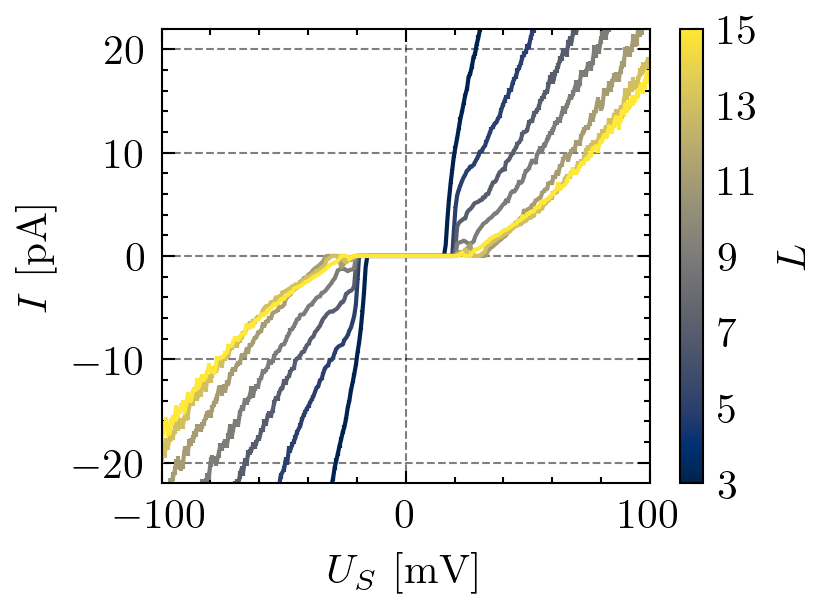

In [53]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=min(L_VALUES),vmax=max(L_VALUES))
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, N in enumerate(L_VALUES):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    _ = ax.errorbar(x, y, y_e, color=cmap(norm(N)))
_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-100,100)
_   = ax.set_ylim(-22,22)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$L$")
_       = cbar.set_ticks(L_VALUES)

fig.savefig(f"plots/svg/network_iv_curves.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves.png", transparent=False)

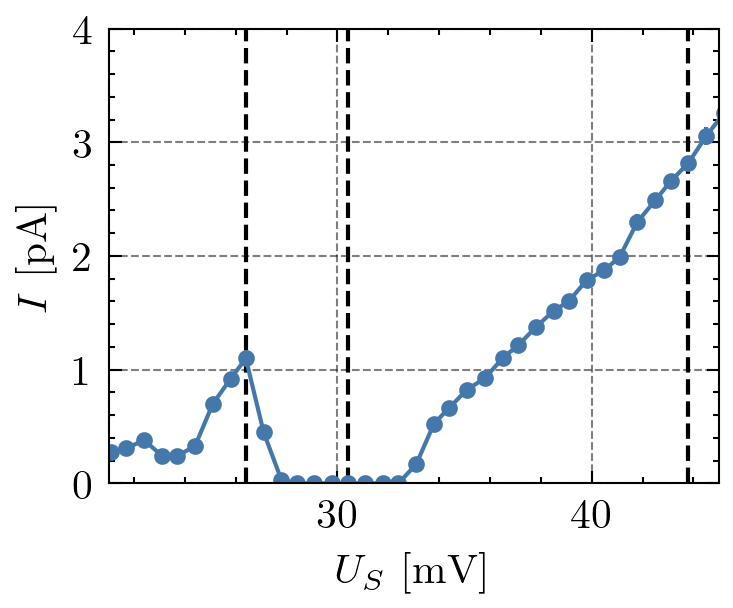

In [198]:
N       = 11
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
df      = data[N].copy().sort_values(by='E0')
x       = df['E0'].values*1000
y       = df['Observable'].values*1e-6
y_e     = df['Error'].values*1e-6
_       = ax.errorbar(x, y, y_e, marker='.')
_       = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_       = ax.set_ylabel("$I~[\mathrm{pA}]$")
_       = ax.set_xlim(21,45)
_       = ax.set_ylim(0,4)
for j in [189, 195, 215]:
    _   = plt.axvline(x[j], color='black', lw=1, ls='--')

fig.savefig(f"plots/svg/11_11_net_IV_state_sample.svg", transparent=True)
fig.savefig(f"plots/pdf/11_11_net_IV_state_sample.pdf", transparent=False)
fig.savefig(f"plots/png/11_11_net_IV_state_sample.png", transparent=False)

In [ ]:
state = {L : pd.read_csv(f"{PATH}mean_state_Nx={L}_Ny={L}_Ne=8.csv") for L in L_VALUES}

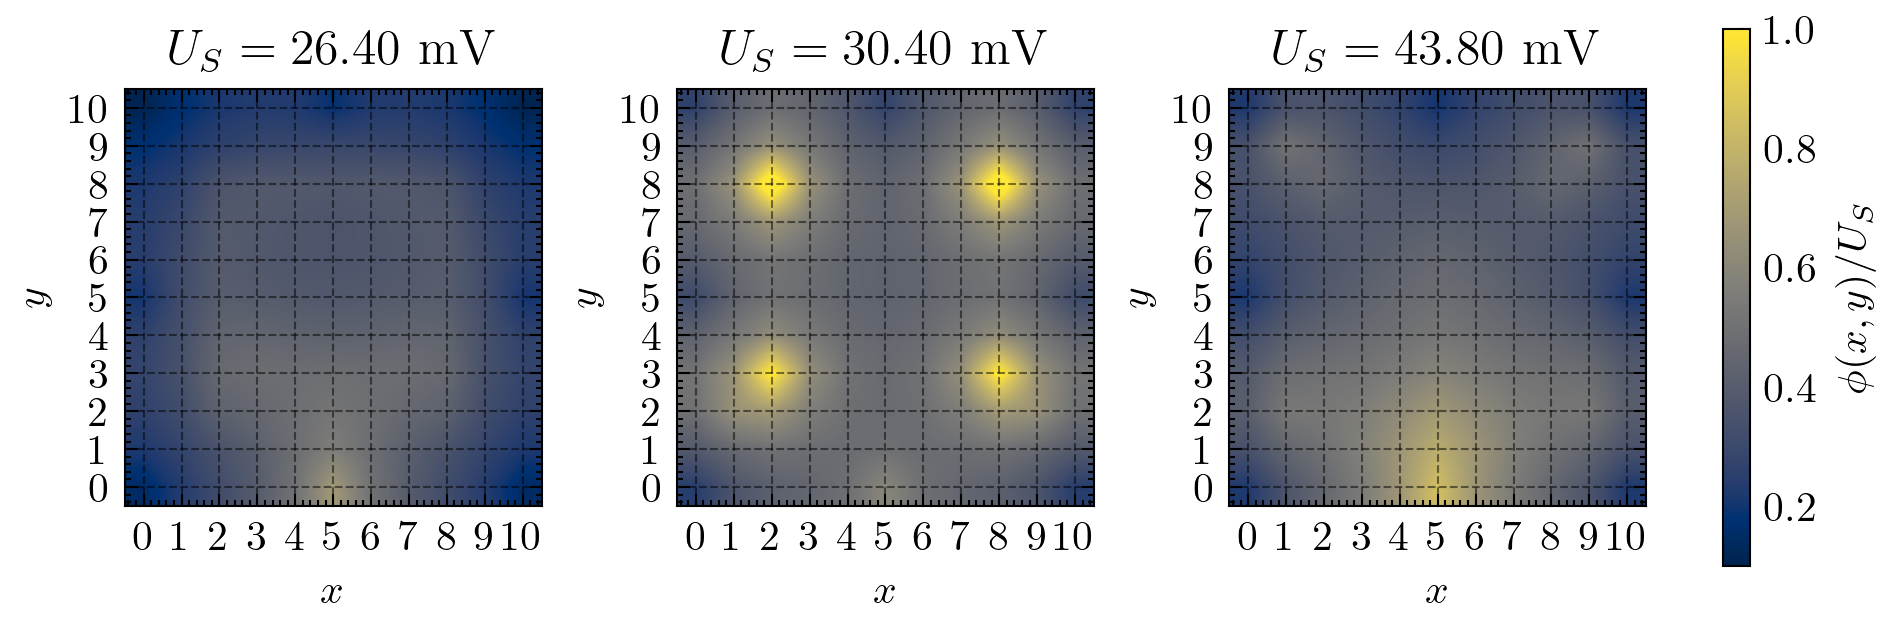

In [199]:
N           = 11
fig, axs    = plt.subplots(1, 3, dpi=300, layout='constrained')
_           = fig.set_figwidth(fig.get_figwidth()*1.8)
_           = fig.set_figheight(fig.get_figheight()*0.8)

j_vals       = [189, 195, 215]
heatmap_axes = [axs[0], axs[1], axs[2]]

for i, j in enumerate(j_vals):
    ax = heatmap_axes[i]
    
    df_state = state[N].sort_values(by='0').reset_index(drop=True)
    U_v = df_state.iloc[j, 0]
    arr = df_state.iloc[j, 8:].values.reshape(N, N) / U_v
    im = ax.imshow(arr, origin='lower', cmap='cividis', vmin=0.1, vmax=1, interpolation='bilinear')
    ax.set_title(f"$U_S = {U_v*1000:.2f}~\mathrm{{mV}}$")
    
    # Tick formatting
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    # ax.set_xticklabels()
    # ax.set_yticklabels("")

    # if i == 0:
    ax.set_ylabel("$y$")
    ax.set_xlabel("$x$")

# --- Colorbar ---
cb = fig.colorbar(im, ax=axs, label='$\phi(x,y) / U_S$')

fig.savefig(f"plots/svg/11_11_net_state_sample.svg", transparent=True)
fig.savefig(f"plots/pdf/11_11_net_state_sample.pdf", transparent=False)
fig.savefig(f"plots/png/11_11_net_state_sample.png", transparent=False)

### Charging Energy Thresholds

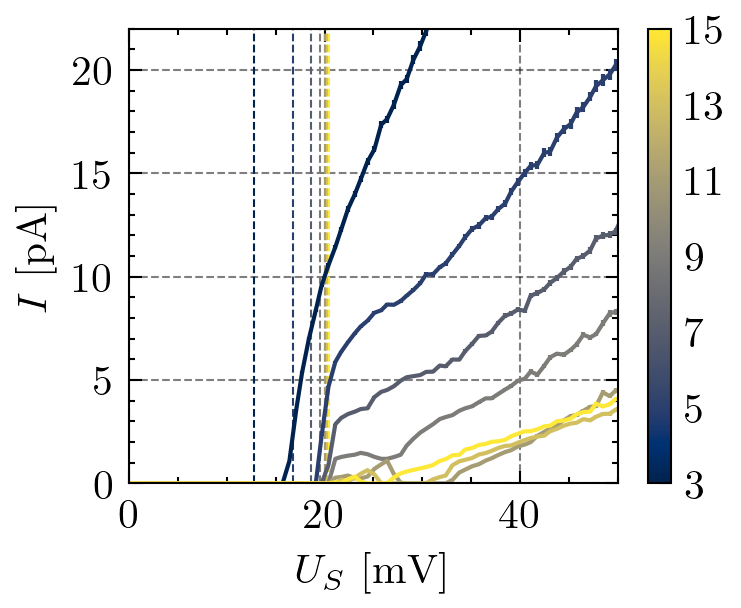

In [37]:
V_TH    = {L+3 : val for L, val in enumerate(np.load(
    "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/charging_energies/edge_mean_0.28.npy"))}

cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=min(L_VALUES),vmax=max(L_VALUES))
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, N in enumerate(L_VALUES):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    pp  = ax.errorbar(x, y, y_e, color=cmap(norm(N)))
    _   = plt.axvline(V_TH[N], color=pp[0].get_color(), ls='--', lw=0.5)

_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(0,50)
_   = ax.set_ylim(0,22)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_ticks(L_VALUES)

fig.savefig(f"plots/svg/network_iv_curves_and_vth.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_and_vth.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_and_vth.png", transparent=False)

### IV-Curves at Cg=0.0

In [38]:
data = {L : pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8_zero.csv") for L in L_VALUES}

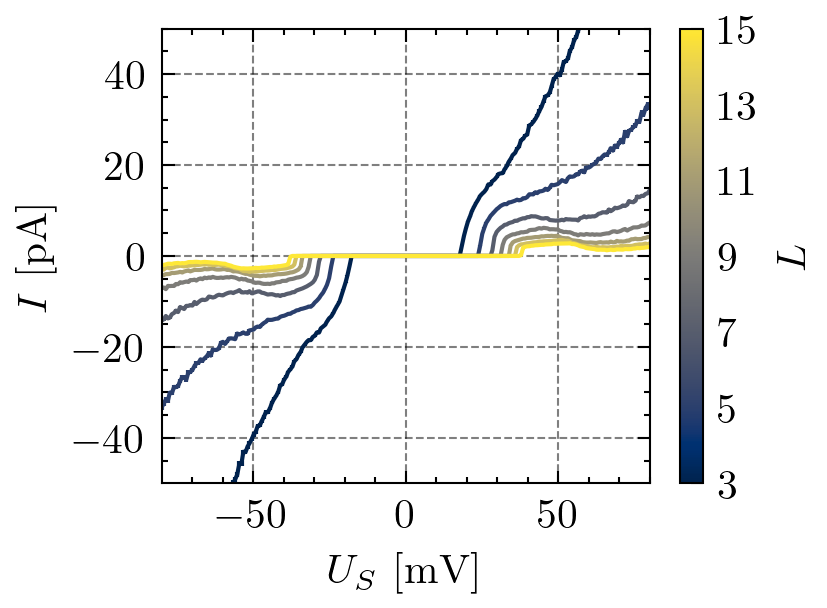

In [39]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=min(L_VALUES),vmax=max(L_VALUES))
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, N in enumerate(L_VALUES):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    _ = ax.errorbar(x, y, y_e, color=cmap(norm(N)))
_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-80,80)
_   = ax.set_ylim(-50,50)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$L$")
_       = cbar.set_ticks(L_VALUES)

fig.savefig(f"plots/svg/network_iv_curves_zero.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_zero.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_zero.png", transparent=False)

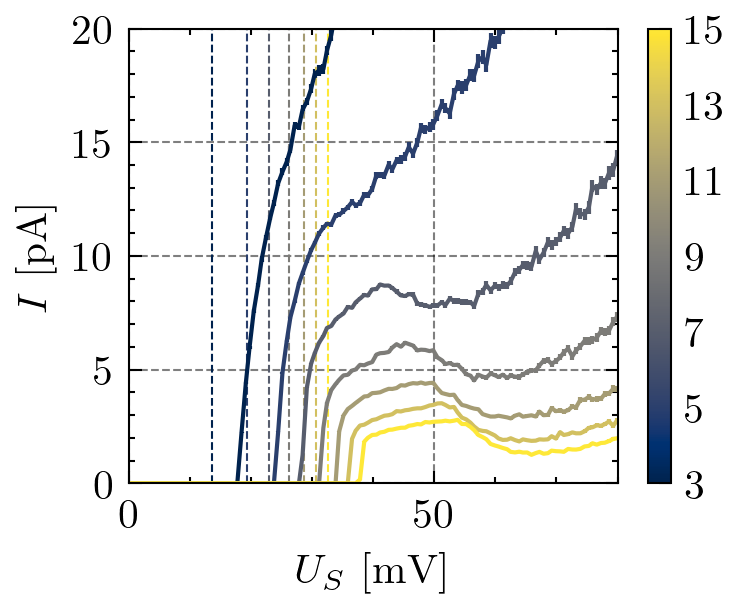

In [40]:
V_TH    = {L+3 : val for L, val in enumerate(
    np.load("/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/charging_energies/edge_mean_zero.npy"))}

cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=min(L_VALUES),vmax=max(L_VALUES))
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
for i, N in enumerate(L_VALUES):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    pp  = ax.errorbar(x, y, y_e, color=cmap(norm(N)))
    _   = plt.axvline(V_TH[N], color=pp[0].get_color(), ls='--', lw=0.5)

_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(0,80)
_   = ax.set_ylim(0,20)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_ticks(L_VALUES)

fig.savefig(f"plots/svg/network_iv_curves_zero_and_vth.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_zero_and_vth.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_zero_and_vth.png", transparent=False)

### Theory

In [41]:
y_theory = {}
for n in L_VALUES:
    topo = {"Nx": n, "Ny": n,
            "e_pos" : [[int((n-1)/2),0],[0,0],[n-1,0],[0,int((n-1)/2)],
            [n-1,int((n)/2)],[0,n-1],[n-1,n-1],[int((n)/2),(n-1)]],
            "electrode_type" : ['constant']*N_E}
    sim_c = Simulation(topo)
    sim_c.build_conductance_matrix()
    sim_c.init_transfer_coeffs()
    G_eff = sim_c.get_transfer_coeffs()[0]
    I_ohm = G_eff * V_INPUT
    y_theory[n] = I_ohm

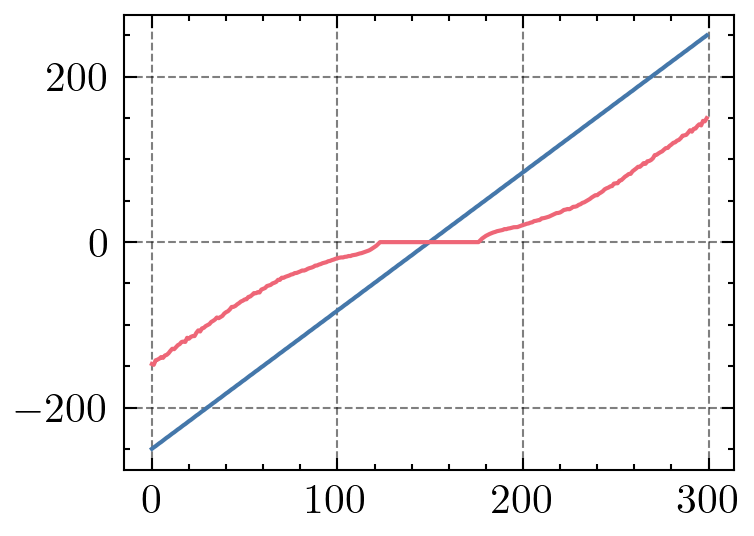

In [42]:
L   = 3
df  = data[L].copy().sort_values(by='E0')
x   = df['E0'].values*1000
y   = df['Observable'].values*1e-6
y_e = df['Error'].values*1e-6


fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
_       = ax.plot(y_theory[L]*1e12)
_       = ax.plot(y)